#### Follow tutorial
https://towardsdatascience.com/advanced-missing-data-imputation-methods-with-sklearn-d9875cbcc6eb

In [11]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
materialData = pd.read_excel('Results_Impute/materialData_ii_imputed.xlsx')
materialData

,materialDensity,materialConductivity,materialHeatCapacity
0,616.710841,0.20160,837.36000
1,7.849047,0.04680,1025.13798
2,10.892555,0.04176,1088.56800
3,13.135140,0.03816,1122.89976
4,22.425849,0.03312,1363.22208
...,...,...,...
250,424.489280,0.11376,1840.51728
251,368.424658,0.12312,1836.33048
252,416.480048,0.11232,1836.33048
253,368.424658,0.09216,1884.06000


## Regression_Prediciton model, Data_IterativeImputation 

In [8]:
from sklearn import preprocessing, svm 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import ShuffleSplit

Axes(0.125,0.11;0.775x0.77)


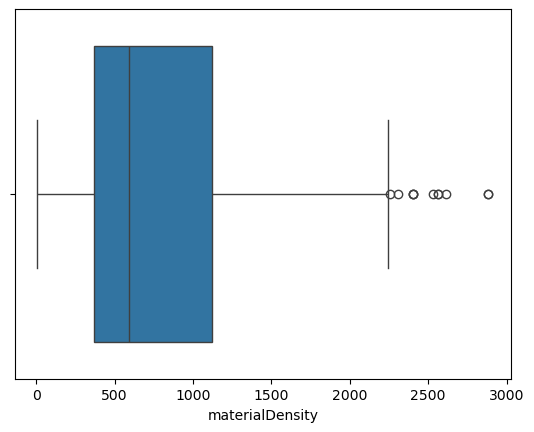

In [12]:
#Make a boxplot fir materialData_ii_imputet
print(sns.boxplot(x=materialData["materialDensity"]))

Axes(0.125,0.11;0.775x0.77)


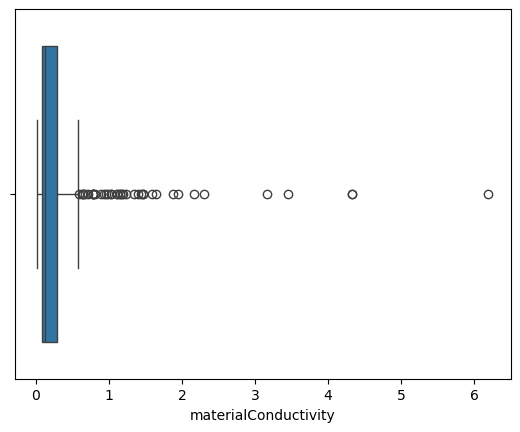

In [17]:
print(sns.boxplot(x=materialData["materialConductivity"]))

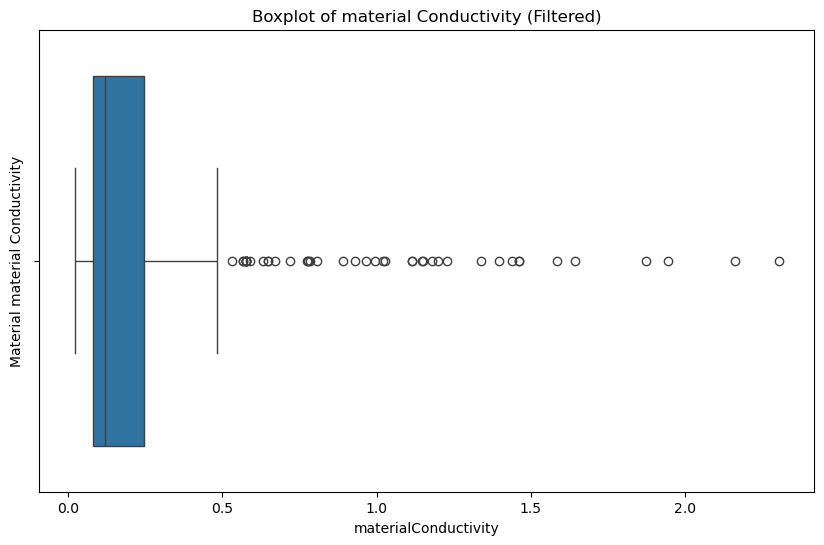

In [19]:
#remove outliers
filtered_data = materialData[
    (materialData.materialConductivity >= 0) & 
    (materialData.materialConductivity <= 3)
]

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=filtered_data.materialConductivity)
plt.title('Boxplot of material Conductivity (Filtered)')
plt.ylabel('Material material Conductivity')
plt.show()

In [21]:
print(filtered_data.materialConductivity)

0      0.20160
1      0.04680
2      0.04176
3      0.03816
4      0.03312
        ...   
250    0.11376
251    0.12312
252    0.11232
253    0.09216
254    0.09936
Name: materialConductivity, Length: 250, dtype: float64


Axes(0.125,0.11;0.775x0.77)


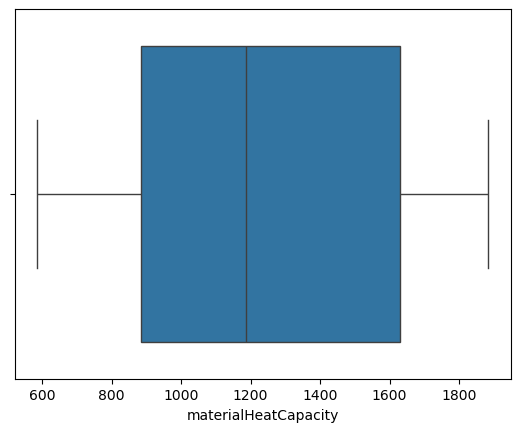

In [25]:
print(sns.boxplot(x=materialData["materialHeatCapacity"]))

## Split and Shuffel Data

In [27]:
#Define dependent and independent variables
##reshape(-1,1) reshapes the column to 1D, 2D array
Y = np.array(materialData.materialDensity).reshape(-1,1)
X = np.array(materialData[['materialConductivity','materialHeatCapacity']])
            
#X2 = np.array(materialData_ii_imputed.materialConductivity).reshape(-1,1)

### Shuffel Split Validation

Shuffle Split is a Random permutation cross-validator.

The method allows to assess the model's performance across different splits of the data, 
which can provide a more robust evaluation of the model.
n_splits=5: Number of re-shuffling & splitting iterations.
test_size=0.25: Proportion of the dataset to include in the test split (25%).
random_state=0: Seed used by the random number generator to ensure reproducibility.

In [97]:
#Create a ShuffleSplit object:
rs = ShuffleSplit(n_splits=7, test_size=.25, random_state=0)

#Print the ShuffleSplit object:
rs.get_n_splits(X)
rs.get_n_splits(Y)

#Generate and print train/test indices for each split:
#multiple feature matrices (e.g., X1,X2,X3), combine to a single feature matrix before splitting the data into training and testing sets. 
for i, (train_index, test_index) in enumerate(rs.split(X, Y)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    Y_train, Y_test = Y[train_index], Y[test_index]
    X_train, X_test = X[train_index], X[test_index]
    
    print(f"  X_train: \n{X_train}")
    print(f"  X_test: \n{X_test}")
    print(f"  Y_train: {Y_train}")
    print(f"  Y_test: {Y_test}")

Fold 0:
  Train: index=[184 248  33 108 156 228 245 214  92  16  96  75 107 176   4 116  61 124
  52  66  26 233 154 226  40  13   3 106  24  30 227  60  56 139 122  19
 190 136  54 204  80  51   2 219 104 134  86  10 144 181 237  41  14  27
  50 235  20 180  46 173 250 123 212 178  62 210 166 130 155 137  43 199
 146 161 112 206  98 160  93 201 243 113   0  94  95  69  49  48  85 252
 141  23 224 143  78 100 131 205 253   6  68  84 121 238 218 240 246 194
  91 217 232  11 119 102  35  57 169  65   1 120 203  42 105 132 220  17
  38 133  53 164 249 128  34  28 183 114 163 151 202  31 209 127 185 225
 236  32 167 142 213 147  29 177  99  82 251 175  79 197 208 115 148 247
  72  77  25 165  81 239 174 244  39 230 193  58 140  88 216  70  87  36
 242  21 211   9 103 195  67 192 117  47 172]
  Test:  index=[158  83 170 101 150 200 118 229  63 135 149 234 109 189 153  73 207 171
 157  97 188  45 241 138 110 254   8  55 221  37 196 126 111 198 168 145
 187   5  22 191 125  12 186 179  90 129

In [99]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()

In [101]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(model, X, Y, cv=rs, scoring='r2')

In [103]:
import numpy as np 

average_r2 = np.mean(scores) 

print(f"R² Score for each fold: {[round(score, 4) for score in scores]}")
print(f"Average R² across {i} folds: {average_r2:.2f}")

R² Score for each fold: [0.4533, 0.6353, 0.6394, 0.5492, 0.6631, 0.6626, 0.648]
Average R² across 6 folds: 0.61


In [71]:
#print(materialData_ii_imputed.columns)

### K-Fold Cross Validation 

This code initializes K-Fold Cross-Validation using the KFold class from sklearn.model_selection. We set up the instance kf with 5 splits. 

In K-Fold Cross-Validation, ‘K’ represents the number of groups into which the dataset is divided. This number determines how many rounds of testing the model undergoes, ensuring each segment is used as a testing set once. 
K= 2 or 3: These choices can be beneficial when computational resources are limited or when a quicker evaluation is needed. 
K= 5 or 10: Choosing K = 5 or K = 10 are popular choices because they provide a good balance between computational efficiency and model performance estimation. 
K = 20: Using a larger value of K can provide a more detailed performance evaluation.

The shuffle=True option randomizes the order of the data points, and the random_state=42 ensures that this shuffling is consistent across multiple runs. This setup is typically sufficient to start evaluating the performance of a model with cross-validation.  


In [39]:
from sklearn.model_selection import KFold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Print the ShuffleSplit object:
kf.get_n_splits(X)
kf.get_n_splits(Y)

#Generate and print train/test indices for each split:
#multiple feature matrices (e.g., X1,X2,X3), combine to a single feature matrix before splitting the data into training and testing sets. 
for i, (train_index, test_index) in enumerate(kf.split(X, Y)):
    print(f"Fold {k}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    Y_train, Y_test = Y[train_index], Y[test_index]
    X_train, X_test = X[train_index], X[test_index]
    
    print(f"  X_train: \n{X_train}")
    print(f"  X_test: \n{X_test}")
    print(f"  Y_train: {Y_train}")
    print(f"  Y_test: {Y_test}")

Fold 5:
  Train: index=[  0   1   2   3   4   5   7   8  11  12  13  14  17  20  21  22  23  26
  27  28  29  31  32  34  35  36  37  38  39  40  41  42  43  44  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  69  70  71  72  73  74  76  77  78  80  81  82  83  84  85  87  88  89
  90  91  92  93  94  95  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 118 119 121 122 123 125 126 127 128 129 130
 131 132 133 134 135 138 139 140 141 142 143 144 145 146 147 149 150 151
 153 154 155 156 157 158 159 160 161 162 163 165 166 168 169 170 171 172
 173 174 175 178 179 182 183 186 187 188 189 191 192 193 194 196 197 199
 202 203 204 207 208 210 211 212 213 214 215 217 218 219 220 223 224 225
 226 227 228 230 231 232 233 235 236 237 239 240 241 242 244 245 246 247
 248 249 250 251 253 254]
  Test:  index=[  6   9  10  15  16  18  19  24  25  30  33  45  66  67  68  75  79  86
  96  97 117 120 124 136 137 148 152 164 167 176 177 180 181

With the data prepared and cross-validation set up, the next step is to choose and initialize the model. The LinearRegression class from sklearn.linear_model is used and create an instance model. This model will be used to perform linear regression on the dataset. 

In [41]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()

Now that the model is initialized, we can move on to the fun part and perform cross-validation to evaluate its performance on different subsets of the data.
This line uses the cross_val_score function to evaluate the model using the dataset X and target y. The cross-validation is conducted using the Kfold instance kf, and the model’s performance is measured using the R² score. 

In [44]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(model, X, Y, cv=kf, scoring='r2')

We can use R-squared as a metric to evaluate the proportion of variance in the dependent variable that is predictable from the independent variables, providing insight into the goodness of fit of the regression model. This part calculates the average R² score for all folds. The scores for each fold are printed first, followed by the average score. The use of np.mean() computes the mean of the scores collected during the cross-validation. 

In [49]:
import numpy as np 

average_r2 = np.mean(scores) 

print(f"R² Score for each fold: {[round(score, 4) for score in scores]}")
print(f"Average R² across {k} folds: {average_r2:.2f}")

R² Score for each fold: [0.7634, 0.5107, 0.712, 0.6186, 0.4215]
Average R² across 5 folds: 0.61


Difference in **KFold and ShuffleSplit output**

KFold will divide your data set into prespecified number of folds, and every sample must be in one and only one fold. A fold is a subset of your dataset.

ShuffleSplit will randomly sample your entire dataset during each iteration to generate a training set and a test set. The test_size and train_size parameters control how large the test and training test set should be for each iteration. Since you are sampling from the entire dataset during each iteration, values selected during one iteration, could be selected again during another iteration.

Summary: ShuffleSplit works iteratively, KFold just divides the dataset into k folds.

Difference when doing validation

In KFold, during each round you will use one fold as the test set and all the remaining folds as your training set. However, in ShuffleSplit, during each round n you should only use the training and test set from iteration n. As your data set grows, cross validation time increases, making shufflesplits a more attractive alternate. If you can train your algorithm, with a certain percentage of your data as opposed to using all k-1 folds, ShuffleSplit is an attractive option.

## Linear Regression 

In [130]:
reg = LinearRegression().fit(X_train, Y_train)

print(reg.score(X_train, Y_train))

print('coef slope', reg.coef_)

print('intercept_final data point for x and y', reg.intercept_)

0.6127034992184845
coef slope [[ 6.01199118e+02 -4.51625750e-01]]
intercept_final data point for x and y [1124.78663752]


In [131]:
# Evaluate the model on the test data
test_score = reg.score(X_test, Y_test)
print("Test R^2 score:", test_score)

Test R^2 score: 0.6479625442957784


In [113]:
pd.DataFrame(X_test).to_csv("X_both column test.csv", index=False)

In [111]:
print(X_test[:,0])

[1.02816   0.072     0.02232   0.16416   0.8928    0.03672   3.456
 0.0472392 0.03024   0.576     0.03528   0.216     0.10512   0.11808
 0.1269648 0.11376   0.20016   0.5688    0.5904    0.2016    0.11376
 0.11808   2.16      0.432     1.22832   0.8064    0.15264   0.648
 0.2166192 0.1152    0.03744   0.04032   0.11448   0.05184   0.03528
 0.2448    0.11376   0.5688    0.144     0.11376   0.09216   1.584
 0.72      0.13104   0.2016    0.42912   0.11376   1.152     0.03312
 0.2482272 0.04176   0.1410192 1.1808    0.11376   0.072     1.6416
 0.1686024 0.0288    0.216     0.648     0.07056   0.11376   1.46112
 1.14768  ]


In [115]:
#reg.predict([[0.03312, 1363.222]])
predicted_Y_for_X_test = reg.predict(X_test)
print(predicted_Y_for_X_test)
#pd.DataFrame(predicted_Y_for_X_test).to_csv("X_test.csv", index=False)

[[1356.13874124]
 [ 638.6303006 ]
 [ 424.21413939]
 [ 617.55125369]
 [1302.27253896]
 [ 610.61287563]
 [2795.99445134]
 [ 752.41760778]
 [ 459.22950346]
 [1017.26932378]
 [ 577.98058849]
 [ 828.44429493]
 [ 601.81601467]
 [ 590.69888833]
 [ 350.22775246]
 [ 361.95405192]
 [ 848.04064794]
 [1060.59053074]
 [1065.25661825]
 [ 867.81504158]
 [ 361.95405192]
 [ 590.69888833]
 [2018.92034757]
 [ 993.09525157]
 [1490.65625691]
 [1231.42026824]
 [ 592.18948961]
 [1118.03800769]
 [ 839.02723756]
 [ 406.68788588]
 [ 769.12219434]
 [ 628.66047265]
 [ 361.25239528]
 [ 767.37969484]
 [ 577.98058849]
 [ 774.28406862]
 [ 361.95405192]
 [1088.57535776]
 [ 477.51394783]
 [ 361.95405192]
 [ 329.30313739]
 [1717.82136943]
 [1179.47666443]
 [ 420.93804664]
 [ 867.81504158]
 [ 985.31302469]
 [ 361.95405192]
 [1445.81271689]
 [ 529.03215779]
 [ 612.21726948]
 [ 771.71937453]
 [ 472.12924679]
 [1445.73127794]
 [ 361.95405192]
 [ 317.18296317]
 [1748.66870525]
 [ 658.89024448]
 [ 428.10990968]
 [ 649.5683059

In [117]:
print('Actual values:', Y_test)
#pd.DataFrame(Y_test).to_csv("Y_test.csv", index=False)

Actual values: [[2210.5479492 ]
 [ 480.553902  ]
 [  31.23600363]
 [ 672.7754628 ]
 [1922.215608  ]
 [  34.43969631]
 [2242.584876  ]
 [ 112.1292438 ]
 [  33.63877314]
 [1922.215608  ]
 [  32.83784997]
 [ 961.107804  ]
 [ 800.92317   ]
 [ 881.015487  ]
 [ 656.7569994 ]
 [ 424.4892801 ]
 [ 640.738536  ]
 [1441.661706  ]
 [1601.84634   ]
 [ 616.7108409 ]
 [ 424.4892801 ]
 [ 881.015487  ]
 [2402.76951   ]
 [1281.477072  ]
 [2002.307925  ]
 [1681.938657  ]
 [ 616.7108409 ]
 [1553.7909498 ]
 [ 897.35431967]
 [ 320.369268  ]
 [ 160.184634  ]
 [  64.0738536 ]
 [ 400.461585  ]
 [ 144.1661706 ]
 [  32.83784997]
 [ 720.830853  ]
 [ 424.4892801 ]
 [2402.76951   ]
 [ 480.553902  ]
 [ 424.4892801 ]
 [ 368.4246582 ]
 [1922.215608  ]
 [1858.1417544 ]
 [ 504.5815971 ]
 [ 616.7108409 ]
 [1601.84634   ]
 [ 424.4892801 ]
 [1601.84634   ]
 [  28.83323412]
 [1121.292438  ]
 [ 120.1384755 ]
 [ 513.15147502]
 [2242.584876  ]
 [ 424.4892801 ]
 [ 416.4800484 ]
 [1954.2525348 ]
 [ 776.09455173]
 [  40.0461585 ]

In [119]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(Y_test, reg.predict(X_test))
mae = mean_absolute_error(Y_test, reg.predict(X_test))

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


Mean Squared Error: 192413.2769001469
Mean Absolute Error: 341.28959062559505


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


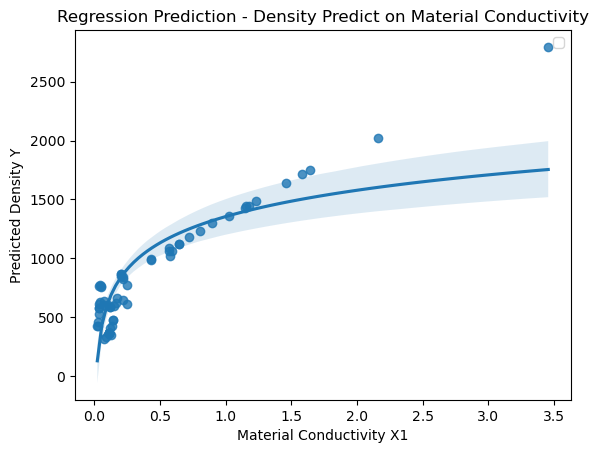

In [121]:
sns.regplot(data=materialData, y=reg.predict(X_test), x= X_test[:,0], logx=True) #predicted density in relation to conductivity

# Adding titles and labels
plt.title('Regression Prediction - Density Predict on Material Conductivity')
plt.xlabel('Material Conductivity X1')
plt.ylabel('Predicted Density Y')
plt.legend()

# Display the plot
#plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


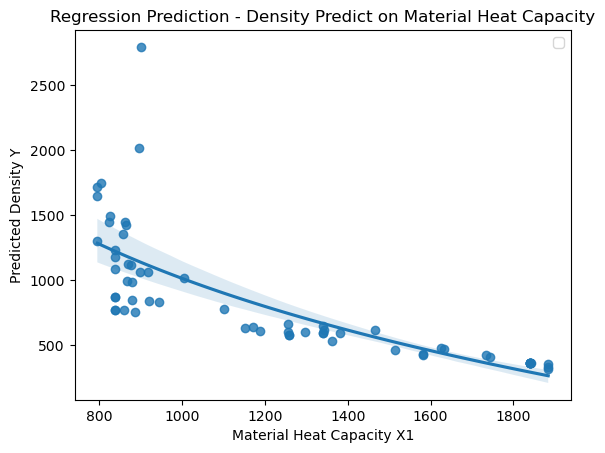

In [123]:
sns.regplot(data=materialData, y=reg.predict(X_test), x= X_test[:,1], logx=True) #predicted density in relation to heat capacity

# Adding titles and labels
plt.title('Regression Prediction - Density Predict on Material Heat Capacity')
plt.xlabel('Material Heat Capacity X1')
plt.ylabel('Predicted Density Y')
plt.legend()


## Ridge Regression

alphas=[0.001,0.1,1,10,1000] are the possible choices the model searches to fit to the data input. it returns the best possible fit

In [73]:
from sklearn.linear_model import RidgeCV

rid = RidgeCV(
    alphas=[0.001,0.1,1,10,1000]
)

rid.fit(X_train, Y_train)
print(rid.alphas)

[0.001, 0.1, 1, 10, 1000]


In [75]:
# Fit the RidgeCV model
rid = RidgeCV(alphas=[0.001, 0.1, 1, 10, 1000])
rid.fit(X_train, Y_train)

# Print the best alpha value
print(f'Best alpha: {rid.alpha_}')

# Print the coefficients and intercept (similar to LinearRegression)
print('Ridge coefficients:', rid.coef_)
print('Ridge intercept:', rid.intercept_)

# Predict using the ridge regression model
predicted_Y_for_X_test_ridge = rid.predict(X_test)
print(predicted_Y_for_X_test_ridge)

# Save the predicted values to a CSV file
#pd.DataFrame(predicted_Y_for_X_test_ridge).to_csv("Y_test_ridge.csv", index=False)

Best alpha: 10.0
Ridge coefficients: [[ 6.53574675e+02 -4.22970589e-01]]
Ridge intercept: [1084.16595661]
[[ 681.15003601]
 [ 514.09621654]
 [ 463.57505096]
 [ 575.247735  ]
 [ 641.46915641]
 [ 561.71404652]
 [ 641.46915641]
 [ 575.247735  ]
 [ 641.46915641]
 [ 889.98238449]
 [ 889.98238449]
 [ 370.24496625]
 [ 602.24234288]
 [ 546.82855649]
 [ 588.83445447]
 [1035.61058634]
 [ 725.47868434]
 [ 594.65421014]
 [1361.67016851]
 [ 380.03193332]
 [ 739.69947435]
 [ 422.05780455]
 [1468.83671485]
 [ 467.80677047]
 [ 876.56818899]
 [1019.58800719]
 [1491.6341887 ]
 [1331.20770653]
 [ 843.09787837]
 [ 380.03193332]
 [ 836.14626204]
 [ 380.03193332]
 [ 380.03193332]
 [ 380.03193332]
 [ 380.03193332]
 [ 380.03193332]
 [4753.6344453 ]
 [1101.7405792 ]
 [1337.0274622 ]
 [1471.59580487]
 [ 897.92876101]
 [ 789.82395104]
 [ 886.21779436]
 [1364.09793702]
 [ 564.78047995]
 [ 422.05780455]
 [1538.01028398]
 [ 616.66765255]
 [ 387.10551975]
 [ 387.92028554]
 [ 352.20316807]]


## Kernel Regression

In [77]:
from sklearn.kernel_ridge import KernelRidge
krr = KernelRidge(
    alpha=[0.001,0.1,1,10,1000]
)

krr.fit(X_train, Y_train)


#krr = KernelRidge(alpha=1.0)
#krr.fit(X, y)
#KernelRidge(alpha=1.0)

KernelRidge(alpha=[0.001, 0.1, 1, 10, 1000])

In [79]:
from sklearn.kernel_ridge import KernelRidge
krr = KernelRidge(
    alpha=[0.001,0.1,1,10,1000]
)

krr.fit(X_train, Y_train)

# Kernel Ridge does not have the attributes coef_ and intercept_. This is because KernelRidge is a kernelized version of ridge regression, which means it doesn't operate in the original feature space but in a higher-dimensional space defined by a kernel function.

# Predict using the ridge regression model
predicted_Y_for_X_test_kernel_ridge = krr.predict(X_test)
print(predicted_Y_for_X_test_kernel_ridge)

# Save the predicted values to a CSV file
#pd.DataFrame(predicted_Y_for_X_test_kernel_ridge).to_csv("Y_test_kernel.csv", index=False)

[[ 346.85803223]
 [ 444.78295898]
 [ 474.84277344]
 [ 404.2532959 ]
 [ 364.27746582]
 [ 459.58532715]
 [ 364.27746582]
 [ 404.2532959 ]
 [ 364.27746582]
 [ 482.06091309]
 [ 482.06091309]
 [ 676.87548828]
 [ 442.45068359]
 [ 476.06665039]
 [ 461.11157227]
 [ 850.01220703]
 [ 547.06860352]
 [ 508.07214355]
 [1214.79272461]
 [ 651.34594727]
 [ 306.72424316]
 [ 624.13085938]
 [1358.52966309]
 [ 555.5625    ]
 [ 681.1661377 ]
 [ 695.88098145]
 [1389.59338379]
 [1093.16149902]
 [ 451.44055176]
 [ 651.34594727]
 [ 479.6036377 ]
 [ 651.34594727]
 [ 651.34594727]
 [ 651.34594727]
 [ 651.34594727]
 [ 651.34594727]
 [6219.9432373 ]
 [ 793.77612305]
 [1140.12158203]
 [1311.71850586]
 [ 598.96166992]
 [ 470.16027832]
 [ 476.51928711]
 [1172.29003906]
 [ 586.00415039]
 [ 624.13085938]
 [1424.64709473]
 [ 549.88146973]
 [ 652.5480957 ]
 [ 659.12353516]
 [ 650.31738281]]


## Model Validation

Evaluation Criteria:
Root Mean Squared Error (RMSE),
prediction accuracy PA, 
residuals means 
residual standard deviations 

In [126]:
#L1 Lasso regression
reg

# Evaluate the model on the test data
reg_test_score = reg.score(X_test, Y_test)
print("Linear R^2 score:", reg_test_score)

Linear R^2 score: 0.6479625442957784


In [128]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

reg_mse = mean_squared_error(Y_test, reg.predict(X_test))
reg_mae = mean_absolute_error(Y_test, reg.predict(X_test))

print("Mean Squared Error:", reg_mse)
print("Mean Absolute Error:", reg_mae)

Mean Squared Error: 192413.2769001469
Mean Absolute Error: 341.28959062559505


In [85]:
#L2 Regularisation 
rid

# Evaluate the model on the test data
rid_test_score = rid.score(X_test, Y_test)
print("Ridge R^2 score:", rid_test_score)

Ridge R^2 score: 0.47850690797975814


In [87]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rid_mse = mean_squared_error(Y_test, rid.predict(X_test))
rid_mae = mean_absolute_error(Y_test, rid.predict(X_test))

print("Mean Squared Error:", rid_mse)
print("Mean Absolute Error:", rid_mae)

Mean Squared Error: 322662.14452981384
Mean Absolute Error: 386.5729950582763


In [89]:
#Kernel
krr

krr_test_score = krr.score(X_test, Y_test)
print("Kernel R^2 score:", krr_test_score)

Kernel R^2 score: 0.08667526485171684


In [91]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

krr_mse = mean_squared_error(Y_test, krr.predict(X_test))
krr_mae = mean_absolute_error(Y_test, krr.predict(X_test))

print("Mean Squared Error:", krr_mse)
print("Mean Absolute Error:", krr_mae)

Mean Squared Error: 565099.1781184145
Mean Absolute Error: 494.91757781434546


In [93]:
modelevalu = ("Linear R^2 score:", reg_test_score, "LIN_MSE:", reg_mse, "LIN_MAE:", reg_mae,
              "Ridge R^2 score:", rid_test_score, "Mean Squared Error:", rid_mse, "Mean Absolute Error:", rid_mae,
              "Kernel R^2 score:", krr_test_score, "Mean Squared Error:", krr_mse,"Mean Absolute Error:", krr_mae)
print(modelevalu)

('Linear R^2 score:', 0.42146545418454906, 'LIN_MSE:', 357955.2636339612, 'LIN_MAE:', 382.56695176262804, 'Ridge R^2 score:', 0.47850690797975814, 'Mean Squared Error:', 322662.14452981384, 'Mean Absolute Error:', 386.5729950582763, 'Kernel R^2 score:', 0.08667526485171684, 'Mean Squared Error:', 565099.1781184145, 'Mean Absolute Error:', 494.91757781434546)


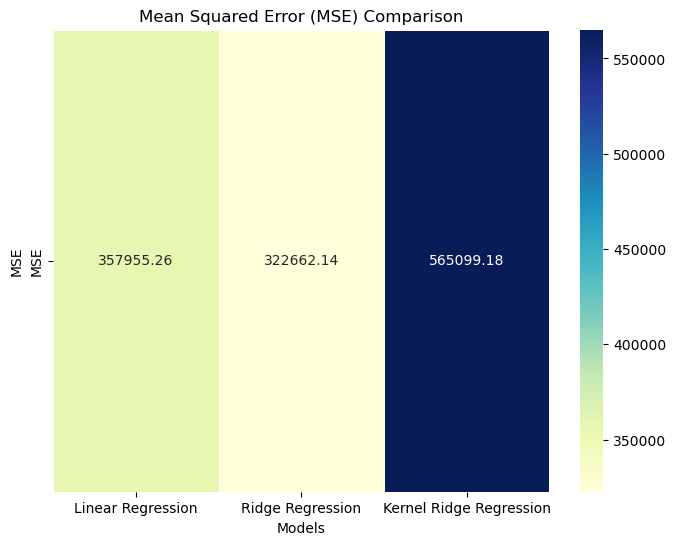

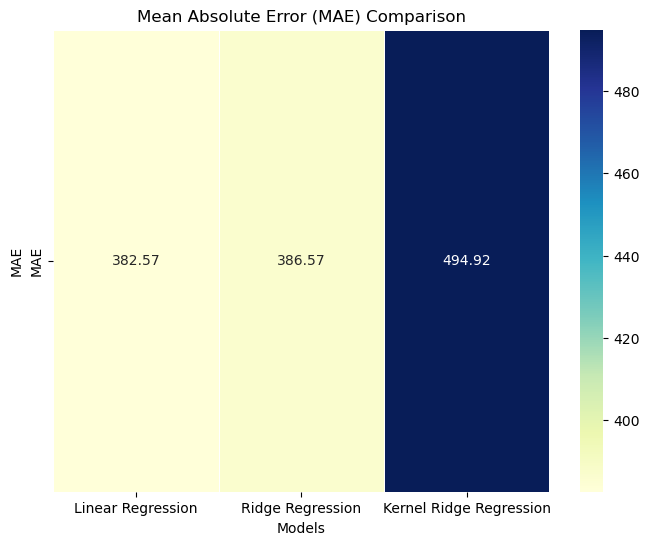

In [95]:
# Labels for the models
models = ['Linear Regression', 'Ridge Regression', 'Kernel Ridge Regression']
mse_values = [reg_mse, rid_mse, krr_mse]
mae_values = [reg_mae, rid_mae, krr_mae]

# Prepare the data for the heatmap
df_mse = pd.DataFrame(mse_values, index=models, columns=['MSE'])
df_mae = pd.DataFrame(mae_values, index=models, columns=['MAE'])


# Plotting the MSE comparison
plt.figure(figsize=(8, 6))
#plt.bar(models, mse_values, color=['blue', 'grey', 'red'])
sns.heatmap(df_mse.T, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Mean Squared Error (MSE) Comparison')
plt.xlabel('Models')
plt.ylabel('MSE')
#plt.ylim(0, max(mse_values) + 1)  # Adjust y-axis for better visualization
plt.show()

# Plotting the MAE comparison
plt.figure(figsize=(8, 6))
#plt.bar(models, mae_values, color=['blue', 'grey', 'red'])
sns.heatmap(df_mae.T, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Mean Absolute Error (MAE) Comparison')
plt.xlabel('Models')
plt.ylabel('MAE')
#plt.ylim(0, max(mae_values) + 1)  # Adjust y-axis for better visualization
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)